# This file will be for the STFT-CNN Pipeline.

For now, it contains data loading, dataframe building, and train/test splitting.

In [1]:
import librosa
import librosa.display
import matplotlib.pyplot as plt
import os
import pandas as pd
import re
from sklearn.model_selection import train_test_split

## Data Loading/Dataframe Building

In [2]:
# change to your directory
folder_path = "D:/DAEN 690/QiandaoEar22-20250621T170333Z-1-001/QiandaoEar22"

#creating empty lists
path= []
signal= []
labels= []

vesselnames= r"""SpeedBoat|Qiandao|KaiYuan|No7|UUV|GreenCity|TheEarl|Cargo|FishBoat|Unknown|TheKnight|
WorkShip|ArtificialSignals|BigPassengerShip|PoliceBoat|MotorBoat|Car|CivilianBoats|No5|Helicopter"""

for filename in os.listdir(folder_path):
    if filename.lower().endswith(".wav"):
        file_path = os.path.join(folder_path, filename)
        # i had some corrupted/empty files
        try:
            y, sr = librosa.load(file_path, sr=22050)
        except Exception as e:
            print(f"Skipping {filename}: {e}")
            
        #get the vessel labels
        label= re.findall(vesselnames, filename)
        combined_label= " ".join(label)
        
        path.append(filename)
        signal.append(y)
        labels.append(combined_label)

C:\Users\annaf\AppData\Local\Temp\ipykernel_55100\1686806192.py:17: UserWarning: PySoundFile failed. Trying audioread instead.
  y, sr = librosa.load(file_path, sr=22050)
C:\Users\annaf\miniconda3\Lib\site-packages\librosa\core\audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)


Skipping 20220626170345_M_QianDao_F_W&SpeedBoat_M_M&SpeedBoat_F_W&SpeedBoat_F_W&SpeedBoat_F_W_0_label__1__8_1.wav: 
Skipping 20220628094211_M_Cargo_N_M&TheEarl_N_M&TheKnight_N_M&QianDao_N_M_2_label__1__25.wav: 
Skipping 20220628095213_M_TheEarl_N_M&TheKnight_N_M&QianDao_M_M&QianDao_M_M_2_label__1__27_1.wav: 
Skipping 20220628095713_M_TheEarl_N_M&TheKnight_N_M&SpeedBoat_F_W&SpeedBoat_F_W_1_label__1__8.wav: 


In [3]:
# zip the lists into a pandas dataframe
df= pd.DataFrame(zip(path, signal, labels), columns= ['path', 'signal', 'labels'])

In [4]:
# identify the vessel of interest

#make sure to use the same capitalization as the documentation lists
vessel_of_interest = 'SpeedBoat'

df[f"{vessel_of_interest}?"]= df['labels'].str.contains(vessel_of_interest, na=False)
df[f"{vessel_of_interest}?"]= df[f"{vessel_of_interest}?"].astype(int)

In [5]:
df.head()

,path,signal,labels,SpeedBoat?
0,20220624101843_S_No7_N_S_0_label__0__10.wav,"[0.0047735204, 0.0051120888, 0.0054790988, 0.0...",No7,0
1,20220624101843_S_No7_N_S_0_label__0__11.wav,"[-0.014467051, -0.026246322, -0.026161099, -0....",No7,0
2,20220624101843_S_No7_N_S_0_label__0__12 - 副本.wav,"[0.0018269685, 0.001574287, -0.0029206066, -0....",No7,0
3,20220624101843_S_No7_N_S_0_label__0__12.wav,"[0.0018269685, 0.001574287, -0.0029206066, -0....",No7,0
4,20220624101843_S_No7_N_S_0_label__0__13 - 副本.wav,"[0.012123276, 0.017119277, 0.009691032, 0.0062...",No7,0


In [9]:
print(df.iloc[:, -1].value_counts())

SpeedBoat?
1    2177
0    1572
Name: count, dtype: int64


<function matplotlib.pyplot.show(close=None, block=None)>

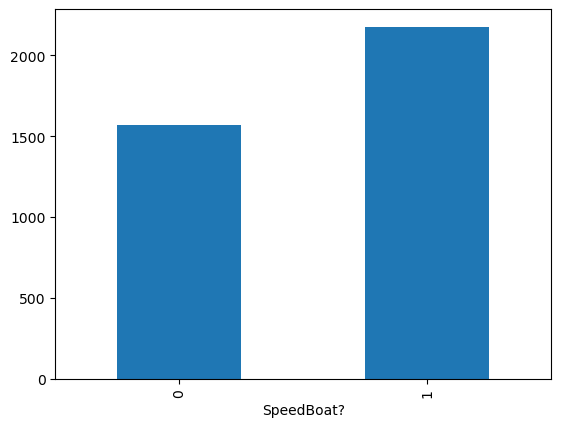

In [10]:
counts= df.iloc[:, -1].value_counts().sort_index()
counts.plot(kind='bar')
plt.show

## Train/Test Split

In [11]:
X= df['signal']
y= df.iloc[:, -1]

X_train, X_test, y_train, y_test= train_test_split(X,y,test_size= 0.3, random_state=100)